In [1]:
# Here I draw up using matplotlib the means by which we ascertained the ultimate compressive strength and
# the young's modulus of samples tested during the course of paper 2's scope.
# I have taken the archetypical sample stress-strain curve to illustrate how we derived the variables of interest.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.patheffects as pe
from CSTMethods import CSTMethods_class
CSTMethods_obj = CSTMethods_class()

Text(0.5, 0, 'Time (mins)')

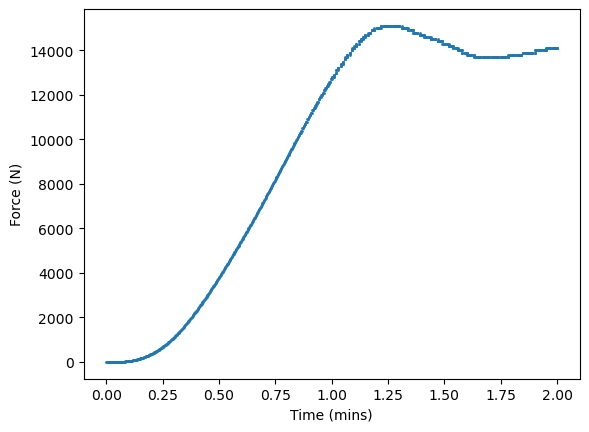

In [3]:
CsvRawDataTrialMT_str = "/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/ExperimentalSeries-2_TOoUPRCS/Method20250310Dim3_CurSys_qLNEI_UCS/RawDataMT/7.csv"
df = pd.read_csv(CsvRawDataTrialMT_str)

plt.scatter(df["Time (min)"],df["Force (N)"],s=1)
plt.ylabel("Force (N)")
plt.xlabel("Time (mins)")

In [4]:
DiameterAvg_mm = np.average(np.array([12.26,12.31,12.22]))
HeightAvg_mm = np.average(np.array([6.49,6.52,6.61]))
DownsamplingFactor_int = 5
HorizonValue_int = 15

cst_df = CSTMethods_obj.DataframeGetter_func(CsvRawDataTrialMT_str)
corr_df = CSTMethods_obj.DataframeGetter_func(CSTMethods_obj.RootPackageLocation_str + CSTMethods_obj.CorrectionalFilePath_str)
cst_df = CSTMethods_obj.DataFrameCorrector(cst_df,corr_df)
cst_df = CSTMethods_obj.StressCalculator_func(cst_df,DiameterAvg_mm)
cst_df = CSTMethods_obj.StrainCalculator_func(cst_df,HeightAvg_mm)
FullResCst_arr = CSTMethods_obj.PandasToNumpy_func(cst_df)
cst_arr = CSTMethods_obj.PandasToDownsampledNumpy_func(cst_df,DownsamplingFactor_int)
strain_arr = cst_arr[3]
strain_arr = np.negative(cst_arr[3])
stress_arr = cst_arr[4]
InflectionIdx_int = CSTMethods_obj.InflectionFinder(cst_arr,HorizonValue_int)
FittedTangentCoeffs_arr,YoungsModulus_flt = CSTMethods_obj.InflectionTangentFinder(cst_arr,InflectionIdx_int,HorizonValue_int)

ucs = CSTMethods_obj.UltimateCompressiveStrengtherWithoutUserInput_func(CsvRawDataTrialMT_str,DiameterAvg_mm,HeightAvg_mm,DownsamplingFactor_int)
pl = CSTMethods_obj.ProportionalLimiterWithoutUserInput_func(CsvRawDataTrialMT_str,DiameterAvg_mm,HeightAvg_mm,DownsamplingFactor_int,HorizonValue_int)
ym  = CSTMethods_obj.YoungsModderWithoutUserInput_func(CsvRawDataTrialMT_str,DiameterAvg_mm,HeightAvg_mm,DownsamplingFactor_int,HorizonValue_int)

def y_func(x,FittedTangentCoeffs_arr):
    return FittedTangentCoeffs_arr[1] + -(FittedTangentCoeffs_arr[0]*x)

xs_arr = np.linspace(-0.042,-0.06,10)
ys_lis = []
for x in xs_arr:
    ys_lis.append(y_func(x,FittedTangentCoeffs_arr))
ys_arr = np.array(ys_lis)

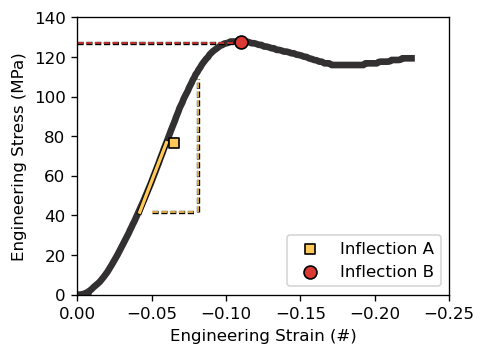

In [5]:
figure(figsize=(4, 3), dpi=120)

plt.plot(xs_arr,ys_arr,color="#ffc857",zorder=5,linewidth=2,path_effects=[pe.Stroke(linewidth=3, foreground='black'),pe.Normal()])
plt.scatter(-0.065,pl,color="#ffc857",edgecolors="black",marker="s",zorder=7,s=40,label="Inflection A")

plt.plot(strain_arr,stress_arr,color="#323031",linewidth=4,zorder=1)

plt.hlines(y=127,xmin=0.00,xmax=-0.11,linewidth=1,color="#db3a34",zorder=2,linestyle="dashed",path_effects=[pe.Stroke(linewidth=2, foreground='black'),pe.Normal()])
plt.scatter(-0.11,ucs,color="#db3a34",edgecolors="black",marker="o",zorder=3,s=60,label="Inflection B")

plt.vlines(x=-0.081,ymin=42,ymax=109,linewidth=1,color="#ffc857",zorder=4,linestyle="dashed",path_effects=[pe.Stroke(linewidth=2, foreground='black'),pe.Normal()])
plt.hlines(y=42,xmin=-0.05,xmax=-0.08,linewidth=1,color="#ffc857",zorder=4,linestyle="dashed",path_effects=[pe.Stroke(linewidth=2, foreground='black'),pe.Normal()])

plt.xlabel("Engineering Strain (#)")
plt.ylabel("Engineering Stress (MPa)")
plt.gca().invert_xaxis()
plt.xlim(0,-0.25)
plt.ylim(0,140)
plt.legend()

In [6]:
# Invert everything because we are dealing with engineering strain for a compressed material...

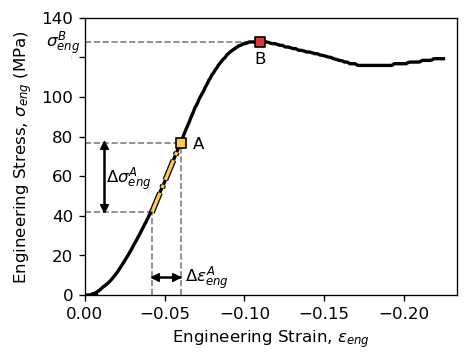

In [7]:
figure(figsize=(4, 3), dpi=120)

# Inflection A and the Tangent
plt.scatter(-0.06,pl,color="#ffc857",edgecolors="black",marker="s",zorder=7,s=30)

# The second inflection point and it's horizontal dashed line
plt.hlines(y=128,xmin=0.00,xmax=-0.11,linewidth=1,color="black",zorder=2,linestyle="dashed",alpha=0.5)
plt.scatter(-0.11,ucs,color="#db3a34",edgecolors="black",marker="s",zorder=3,s=40)

# Tangent through A
plt.plot(xs_arr,ys_arr,color="#ffc857",zorder=3,linewidth=2,path_effects=[pe.Stroke(linewidth=3.5, foreground='black'),pe.Normal()],linestyle="-.")

# The label for the inflection point B
plt.text(x=0.023,y=120,s="   ",fontsize=10,backgroundcolor="white")
plt.text(x=0.024,y=125,s=r"$\sigma _{eng} ^{B}$",fontsize=10)

# The underlying dataset in green
plt.plot(strain_arr,stress_arr,color="black",linewidth=2,zorder=1)

# The vertical and horizontal black dashed lines fitted to the tangent
plt.vlines(x=-0.06,ymin=0,ymax=77,linewidth=1,color="black",zorder=4,linestyle="dashed",alpha=0.5)
plt.vlines(x=-0.042,ymin=0,ymax=42,linewidth=1,color="black",zorder=4,linestyle="dashed",alpha=0.5)
plt.hlines(y=42,xmin=0,xmax=-0.042,linewidth=1,color="black",zorder=4,linestyle="dashed",alpha=0.5)
plt.hlines(y=77,xmin=0,xmax=-0.06,linewidth=1,color="black",zorder=4,linestyle="dashed",alpha=0.5)

# The horizontal measurement
plt.text(x=-0.063,y=6,s=r"$\Delta \epsilon _{eng} ^{A}$")
plt.hlines(y=9,xmin=-0.042,xmax=-0.06,color="black")
plt.scatter(-0.057,9,marker=">",color="black",s=20)
plt.scatter(-0.044,9,marker="<",color="black",s=20)

# The vertical measurement
plt.text(x=-0.013,y=56,s=r"$\Delta \sigma _{eng} ^{A}$")
plt.vlines(x=-0.012,ymin=42,ymax=76,color="black")
plt.scatter(-0.012,76,marker="^",color="black",s=20)
plt.scatter(-0.012,44,marker="v",color="black",s=20)

# Inflection Point Labels
plt.text(x=-0.068,y=74,s="A")
plt.text(x=-0.106,y=117,s="B")

# The basics
plt.xlabel(r"Engineering Strain, $\epsilon_{eng}$")
plt.ylabel(r"Engineering Stress, $\sigma_{eng}$ (MPa)")
plt.gca().invert_xaxis()
plt.xlim(0,-0.233)
plt.ylim(0,140)

plt.savefig("ExampleStressStrain.jpg", bbox_inches="tight", pad_inches=0.05, transparent=False)

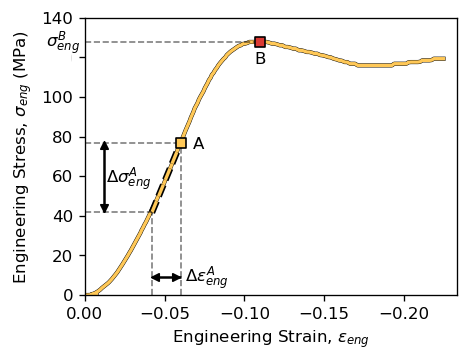

In [8]:
figure(figsize=(4, 3), dpi=120)

# Inflection A and the Tangent
plt.scatter(-0.06,pl,color="#ffc857",edgecolors="black",marker="s",zorder=7,s=30)

# The second inflection point and it's horizontal dashed line
plt.hlines(y=128,xmin=0.00,xmax=-0.11,linewidth=1,color="black",zorder=2,linestyle="dashed",alpha=0.5)
plt.scatter(-0.11,ucs,color="#db3a34",edgecolors="black",marker="s",zorder=3,s=40)

# Tangent through A
plt.plot(xs_arr,ys_arr,color="#ffc857",zorder=3,linewidth=2,path_effects=[pe.Stroke(linewidth=4, foreground='black'),pe.Normal()],linestyle="--")

# The label for the inflection point B
plt.text(x=0.023,y=120,s="   ",fontsize=10,backgroundcolor="white")
plt.text(x=0.024,y=125,s=r"$\sigma _{eng} ^{B}$",fontsize=10)

# The underlying dataset in green
plt.plot(strain_arr,stress_arr,color="#ffc857",linewidth=2,zorder=1,path_effects=[pe.Stroke(linewidth=2.5, foreground='black'),pe.Normal()])

# The vertical and horizontal black dashed lines fitted to the tangent
plt.vlines(x=-0.06,ymin=0,ymax=77,linewidth=1,color="black",zorder=4,linestyle="dashed",alpha=0.5)
plt.vlines(x=-0.042,ymin=0,ymax=42,linewidth=1,color="black",zorder=4,linestyle="dashed",alpha=0.5)
plt.hlines(y=42,xmin=0,xmax=-0.042,linewidth=1,color="black",zorder=4,linestyle="dashed",alpha=0.5)
plt.hlines(y=77,xmin=0,xmax=-0.06,linewidth=1,color="black",zorder=4,linestyle="dashed",alpha=0.5)

# The horizontal measurement
plt.text(x=-0.063,y=6,s=r"$\Delta \epsilon _{eng} ^{A}$")
plt.hlines(y=9,xmin=-0.042,xmax=-0.06,color="black")
plt.scatter(-0.057,9,marker=">",color="black",s=20)
plt.scatter(-0.044,9,marker="<",color="black",s=20)

# The vertical measurement
plt.text(x=-0.013,y=56,s=r"$\Delta \sigma _{eng} ^{A}$")
plt.vlines(x=-0.012,ymin=42,ymax=76,color="black")
plt.scatter(-0.012,76,marker="^",color="black",s=20)
plt.scatter(-0.012,44,marker="v",color="black",s=20)

# Inflection Point Labels
plt.text(x=-0.068,y=74,s="A")
plt.text(x=-0.106,y=117,s="B")

# The basics
plt.xlabel(r"Engineering Strain, $\epsilon_{eng}$")
plt.ylabel(r"Engineering Stress, $\sigma_{eng}$ (MPa)")
plt.gca().invert_xaxis()
plt.xlim(0,-0.233)
plt.ylim(0,140)

# plt.savefig("ExampleStressStrain.jpg", bbox_inches="tight", pad_inches=0.05, transparent=False)

plt.savefig(fname='ExampleStressStrain.pdf',bbox_inches="tight",dpi=1000,format='pdf')